# Clasificación de Texto mediante Retrieval-Augmented Generation (RAG)

En este notebook implementaremos un sistema de clasificación de texto utilizando la técnica de Retrieval-Augmented Generation (RAG). A diferencia de los enfoques tradicionales de fine-tuning, RAG combina un sistema de recuperación de documentos con un modelo de lenguaje para realizar clasificaciones basadas en ejemplos similares recuperados del corpus.

## Objetivo

Implementar un clasificador de sentimientos para reseñas en español utilizando un enfoque RAG. El sistema recuperará ejemplos similares del corpus y utilizará un LLM para determinar la clasificación basándose en estos ejemplos en un contexto few-shot.

## Metodología

1. **Retriever**: Utilizaremos embeddings semánticos para recuperar los ejemplos más similares del corpus
2. **Generator**: Un LLM (llama3.2:3b) actuará como clasificador usando los ejemplos recuperados como contexto
3. **Integración**: LangChain orquestará la cadena completa de recuperación y clasificación

### Referencias
- [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](http://arxiv.org/abs/2005.11401)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [LangChain Documentation](https://www.langchain.com)
- [Ollama](https://ollama.com)

In [33]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

## Instalación de dependencias

Instalamos las librerías necesarias para implementar el RAG-classifier:
- **langchain-ollama**: Integración de Ollama con LangChain
- **langchain-community**: Componentes adicionales de LangChain
- **langchain-huggingface**: Integración de HuggingFace con LangChain
- **ollama**: Cliente para interactuar con modelos de Ollama
- **faiss-gpu**: Base de datos vectorial optimizada para GPU
- **sentence-transformers**: Modelos de embeddings semánticos
- **datasets**: Carga de datasets desde HuggingFace
- **gradio**: Interfaz de usuario para pruebas interactivas

In [34]:
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 lshw -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install langchain-ollama langchain-community langchain-huggingface ollama faiss-gpu sentence-transformers datasets gradio colab-xterm

'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.


## Configuración de Ollama

Ollama es una herramienta que facilita la ejecución local de grandes modelos de lenguaje. Instalamos Ollama y descargamos el modelo llama3.2:3b, que es un modelo compacto pero capaz, adecuado para entornos con recursos limitados.

In [35]:
!if ! type ollama > /dev/null; then curl -fsSL https://ollama.com/install.sh | sh; else echo "Ollama ya está instalado."; fi

type was unexpected at this time.


### Importante
Si estás ejecutando este notebook en Colab, descomenta las siguientes líneas y ejecuta `ollama serve &` en la terminal que se abre.

In [36]:
# %load_ext colabxterm
# %xterm

In [37]:
# Descargamos el modelo llama3.2:3b
!ollama pull llama3.2:3b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest 
pulling dde5aa3fc5ff: 100% ▕██████████████████▏ 2.0 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 56bb8bd477a5: 100% ▕██████████████████▏   96 B                         
pulling 34bb5ab01051: 100% ▕██████████████████▏  561 B                         
verifying sha256 digest 
writing manifest 
success 


## Carga y Preparación del Corpus

Utilizaremos un dataset de reseñas en español para la tarea de clasificación de sentimientos. Este dataset contiene reseñas etiquetadas como positivas o negativas, lo que nos permite evaluar la capacidad del RAG-classifier para determinar el sentimiento basándose en ejemplos similares.

In [38]:
from datasets import load_dataset
import pandas as pd

# Cargamos el dataset de análisis de sentimientos en español
# Usamos 'sepidmnorozy/Spanish_sentiment' que contiene reseñas con sentimientos
dataset = load_dataset('sepidmnorozy/Spanish_sentiment', split='train')
dataset

Dataset({
    features: ['label', 'text'],
    num_rows: 1029
})

In [39]:
# Configuramos pandas para mejor visualización
pd.set_option('display.max_colwidth', 150)

# Convertimos a pandas para análisis exploratorio
dataset.set_format(type='pandas')
df = dataset[:]

# Mostramos las primeras filas
df.head(10)

,label,text
0,1,"Está situado en el centro de la ciudad , con todo lo más turístico a tu alrededor ( El Pilar , por ejemplo ) , y sitios para tomar algo ."
1,1,"un lugar hermosisimo , inolvidable. hermosa atención · rescato el servicio , como asi también la calidez de su gente y el hermoso entorno natural...."
2,1,Todo absolutamente recomendable .
3,1,El metro está a 50 metros bajando tan solo una calle .
4,1,Y de Toscana ... mejor que lo veais ... y además delo bonito que es Florencia y Siena ... perderos por sus pueblos ..
5,1,"El hotel esta bien , por el precio que pagas , buena ubicación cerca de la estación de trenes Santa Maria Novella ,"
6,1,"Las habitaciones eran perfectas , están repartidas en diferentes casas ."
7,0,El peor hotel de punta cana !
8,1,Nada caro para el lugar donde esta y las comodidades que ofrece .
9,1,Buena calidad / precico


### Análisis Exploratorio del Dataset

Realizamos un análisis exploratorio para entender la distribución de sentimientos y la longitud de las reseñas.

Distribución de sentimientos:
label
1    851
0    178
Name: count, dtype: int64

Total de ejemplos: 1029


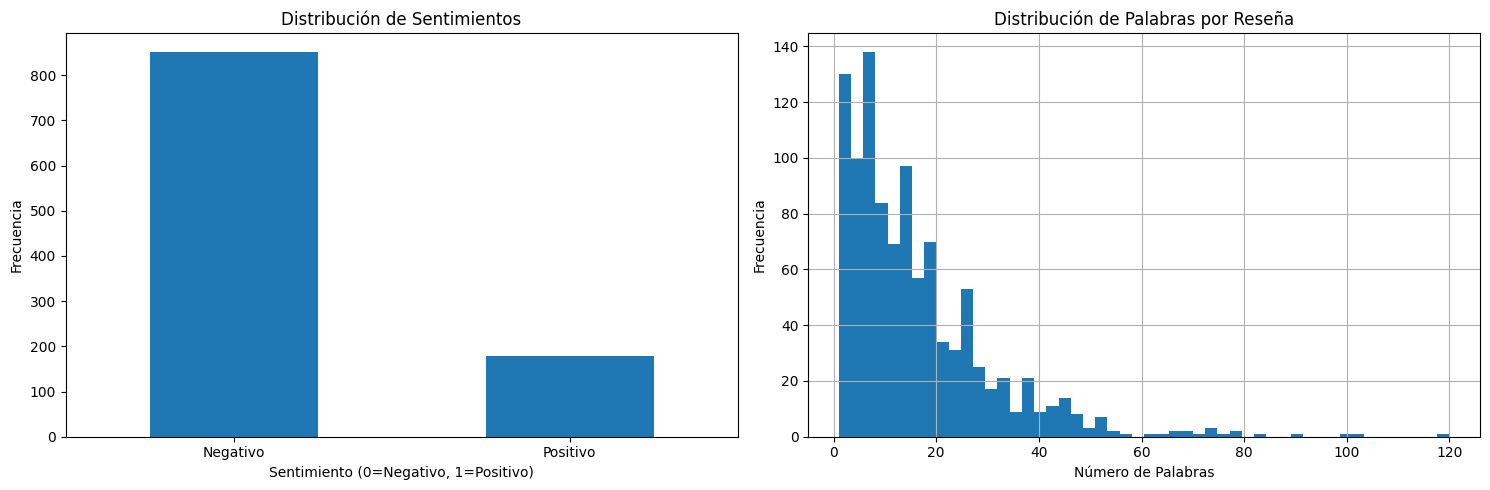

In [40]:
import matplotlib.pyplot as plt

# Análisis de la distribución de clases
print("Distribución de sentimientos:")
print(df['label'].value_counts())
print(f"\nTotal de ejemplos: {len(df)}")

# Visualización de la distribución
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de clases
df['label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución de Sentimientos')
axes[0].set_xlabel('Sentimiento (0=Negativo, 1=Positivo)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['Negativo', 'Positivo'], rotation=0)

# Distribución de longitud de textos
df['text'].str.split().apply(len).hist(bins=50, ax=axes[1])
axes[1].set_title('Distribución de Palabras por Reseña')
axes[1].set_xlabel('Número de Palabras')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [41]:
# Estadísticas descriptivas
palabras_por_review = df['text'].str.split().apply(len)
print(f"Estadísticas de longitud de reseñas:")
print(f"Media: {palabras_por_review.mean():.2f} palabras")
print(f"Mediana: {palabras_por_review.median():.2f} palabras")
print(f"Desviación estándar: {palabras_por_review.std():.2f} palabras")
print(f"Mínimo: {palabras_por_review.min()} palabras")
print(f"Máximo: {palabras_por_review.max()} palabras")

Estadísticas de longitud de reseñas:
Media: 16.29 palabras
Mediana: 12.00 palabras
Desviación estándar: 14.44 palabras
Mínimo: 1 palabras
Máximo: 120 palabras


### Preparación del Corpus para RAG

Para implementar RAG-classifier, necesitamos preparar el corpus de manera que cada documento contenga tanto el texto como su etiqueta de clasificación. Limitamos el tamaño del corpus para optimizar el rendimiento en hardware limitado.

In [42]:
# Limitamos el dataset para eficiencia computacional
limit = 2000  # Usamos hasta 2000 ejemplos para el vector store
dataset.reset_format()

# Verificamos cuántos ejemplos hay de cada clase
label_counts = df['label'].value_counts()
print(f"Ejemplos por clase en el dataset original:")
print(label_counts)

# Tomamos la cantidad mínima disponible entre clases o limit/2
min_samples = min(label_counts.min(), limit // 2)
print(f"\nTomaremos {min_samples} ejemplos de cada clase para un total de {min_samples * 2} ejemplos")

# Creamos una versión reducida del dataset balanceada
df_balanced = df.groupby('label').sample(n=min_samples, random_state=42)
indices = df_balanced.index.tolist()
subset = dataset.select(indices)

print(f"\nDataset balanceado creado con {len(subset)} ejemplos")

# Creamos textos enriquecidos con la etiqueta para el vector store
# Esto ayuda al retriever a encontrar ejemplos del mismo sentimiento
def prepare_examples(example):
    sentiment = "positivo" if example['label'] == 1 else "negativo"
    # Formato: "Sentimiento: [etiqueta] Reseña: [texto]"
    text = f"Sentimiento: {sentiment}\nReseña: {example['text']}"
    return {
        'text': text,
        'label': example['label'],
        'sentiment': sentiment,
        'original_text': example['text']
    }

prepared_dataset = subset.map(prepare_examples)
print(f"\nDataset preparado con {len(prepared_dataset)} ejemplos")

# Mostramos un ejemplo preparado
print("\nEjemplo preparado:")
print(prepared_dataset[0])

Ejemplos por clase en el dataset original:
label
1    851
0    178
Name: count, dtype: int64

Tomaremos 178 ejemplos de cada clase para un total de 356 ejemplos

Dataset balanceado creado con 356 ejemplos


Map:   0%|          | 0/356 [00:00<?, ? examples/s]


Dataset preparado con 356 ejemplos

Ejemplo preparado:
{'label': 0, 'text': 'Sentimiento: negativo\nReseña: El servicio de habitaciones , limpieza , etc ... pésimo .', 'sentiment': 'negativo', 'original_text': 'El servicio de habitaciones , limpieza , etc ... pésimo .'}


## Implementación del RAG-Classifier

### 1. Configuración del Retriever

El retriever es responsable de encontrar los ejemplos más similares del corpus. Utilizamos:
- **Embeddings**: Modelo multilingual-e5-small para generar representaciones semánticas
- **Vector Store**: FAISS para búsqueda eficiente de similitud

In [43]:
import os
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Configuramos el modelo de embeddings
# Usamos multilingual-e5-small que es compacto pero efectivo para español
embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-small",
    model_kwargs={'device': 'cuda' if IN_COLAB else 'cpu'}  # Usamos GPU si está disponible
)

# Creamos o cargamos el vector store
index_path = './faiss_index_sentiment'

if os.path.exists(index_path):
    print("Cargando vector store existente...")
    vectorstore = FAISS.load_local(
        index_path, 
        embeddings, 
        allow_dangerous_deserialization=True
    )
else:
    print("Creando nuevo vector store...")
    # Extraemos los textos preparados
    texts = [example['text'] for example in prepared_dataset]
    
    # Creamos metadatos para cada documento
    metadatas = [
        {
            'label': example['label'],
            'sentiment': example['sentiment'],
            'original_text': example['original_text']
        }
        for example in prepared_dataset
    ]
    
    # Creamos el vector store
    vectorstore = FAISS.from_texts(
        texts, 
        embeddings,
        metadatas=metadatas
    )
    
    # Guardamos para uso futuro
    vectorstore.save_local(index_path)
    print(f"Vector store guardado en {index_path}")

print(f"Vector store listo con {vectorstore.index.ntotal} documentos")

W1029 12:18:17.305764 65796 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Creando nuevo vector store...
Vector store guardado en ./faiss_index_sentiment
Vector store listo con 356 documentos
Vector store guardado en ./faiss_index_sentiment
Vector store listo con 356 documentos


In [44]:
# Configuramos el retriever
# k=5 significa que recuperaremos los 5 ejemplos más similares
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

# Probamos el retriever con un ejemplo
test_query = "Esta película es excelente, me encantó la actuación"
retrieved_docs = retriever.get_relevant_documents(test_query)

print(f"Documentos recuperados para: '{test_query}'\n")
for i, doc in enumerate(retrieved_docs, 1):
    print(f"[{i}] Sentimiento: {doc.metadata['sentiment']}")
    print(f"    Texto: {doc.metadata['original_text'][:100]}...")
    print()

Documentos recuperados para: 'Esta película es excelente, me encantó la actuación'

[1] Sentimiento: positivo
    Texto: Encanto real...

[2] Sentimiento: positivo
    Texto: El desayuno me encantó , riquisimo y super variado ....

[3] Sentimiento: positivo
    Texto: Realmente lo recomiendo ,...

[4] Sentimiento: positivo
    Texto: Muy bueno...

[5] Sentimiento: positivo
    Texto: Una buena combinación...



C:\Users\andres.borreroc\AppData\Local\Temp\ipykernel_65796\2578433423.py:10: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use invoke instead.
  retrieved_docs = retriever.get_relevant_documents(test_query)


### 2. Configuración del Generator (LLM)

El LLM actúa como el clasificador final. Utilizamos llama3.2:3b a través de Ollama. El modelo recibirá los ejemplos recuperados como contexto y determinará la clasificación del texto de entrada.

In [45]:
from langchain_ollama import ChatOllama

# Instanciamos el LLM
llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.1  # Temperatura baja para respuestas más consistentes
)

# Verificamos que funciona
test_response = llm.invoke("Di 'OK' si estás funcionando")
print(f"LLM responde: {test_response.content}")

LLM responde: ¡Hola! Me alegra saber que estoy funcionando correctamente. ¿En qué puedo ayudarte hoy?


### 3. Diseño del Prompt para Clasificación

El prompt es crucial en un RAG-classifier. Debe instruir al LLM para que:
1. Analice los ejemplos recuperados (contexto)
2. Identifique patrones de sentimiento
3. Clasifique el texto de entrada basándose en esos patrones
4. Responda en un formato estructurado

In [46]:
from langchain_core.prompts import ChatPromptTemplate

# Definimos el template del prompt para clasificación
classification_prompt = ChatPromptTemplate.from_messages([
    ("system", """Eres un clasificador de sentimientos experto. Tu tarea es determinar si una reseña es POSITIVA o NEGATIVA.

A continuación se te proporcionan algunos ejemplos de reseñas clasificadas del corpus:

{context}

Basándote en estos ejemplos, analiza cuidadosamente el sentimiento de la siguiente reseña.
Debes responder ÚNICAMENTE con una de estas dos palabras: POSITIVO o NEGATIVO.
No proporciones explicaciones adicionales, solo la clasificación."""
    ),
    ("human", "Clasifica el sentimiento de esta reseña:\n\n{input}")
])

print("Prompt de clasificación configurado")

Prompt de clasificación configurado


### 4. Construcción de la Cadena RAG

Integramos todos los componentes usando LangChain. La cadena completa:
1. Recibe el texto de entrada
2. Recupera ejemplos similares (Retriever)
3. Construye el prompt con los ejemplos como contexto
4. Invoca al LLM para clasificar (Generator)
5. Retorna la clasificación y el contexto utilizado

In [47]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain

# Creamos la cadena de combinación de documentos con el prompt
combine_docs_chain = create_stuff_documents_chain(llm, classification_prompt)

# Creamos la cadena RAG completa
rag_chain = create_retrieval_chain(retriever, combine_docs_chain)

print("Cadena RAG-Classifier creada exitosamente")

Cadena RAG-Classifier creada exitosamente


### Función Helper para Formatear Resultados

Creamos una función para mostrar de forma clara los resultados de la clasificación, incluyendo los documentos recuperados que el modelo usó como contexto.

In [48]:
def format_classification_result(result):
    """
    Formatea el resultado de la clasificación para mejor visualización.
    
    Args:
        result: Diccionario con 'input', 'answer' y 'context'
    
    Returns:
        String formateado con la clasificación y ejemplos usados
    """
    output = []
    output.append("=" * 80)
    output.append(f"TEXTO DE ENTRADA:")
    output.append(f"{result['input']}")
    output.append("\n" + "-" * 80)
    output.append(f"CLASIFICACIÓN: {result['answer']}")
    output.append("-" * 80)
    output.append(f"\nEJEMPLOS RECUPERADOS (usados como contexto):")
    output.append("")
    
    for i, doc in enumerate(result['context'], 1):
        sentiment = doc.metadata['sentiment'].upper()
        text = doc.metadata['original_text']
        output.append(f"[{i}] Sentimiento: {sentiment}")
        output.append(f"    Texto: {text[:200]}...")
        output.append("")
    
    output.append("=" * 80)
    return "\n".join(output)

print("Función de formateo lista")

Función de formateo lista


## Resultados y Evaluación

Probamos el RAG-classifier con diferentes ejemplos de reseñas que no están en el corpus de entrenamiento. Observaremos:
1. La clasificación predicha por el sistema
2. Los ejemplos recuperados que influenciaron la decisión
3. La coherencia entre los ejemplos recuperados y la clasificación

### Ejemplo 1: Reseña Positiva Clara

In [49]:
test_text_1 = """Esta película superó todas mis expectativas. La dirección es magistral, las actuaciones son soberbias y la fotografía es simplemente impresionante. Una obra maestra del cine contemporáneo que recomiendo absolutamente."""

result_1 = rag_chain.invoke({"input": test_text_1})
print(format_classification_result(result_1))

TEXTO DE ENTRADA:
Esta película superó todas mis expectativas. La dirección es magistral, las actuaciones son soberbias y la fotografía es simplemente impresionante. Una obra maestra del cine contemporáneo que recomiendo absolutamente.

--------------------------------------------------------------------------------
CLASIFICACIÓN: POSITIVO
--------------------------------------------------------------------------------

EJEMPLOS RECUPERADOS (usados como contexto):

[1] Sentimiento: POSITIVO
    Texto: Todo absolutamente recomendable ....

[2] Sentimiento: POSITIVO
    Texto: os la la recomiendo a todas las personas q se pasen por la ciudad es grande y muy calida bueno espero aver ayudado...

[3] Sentimiento: POSITIVO
    Texto: Un gran hotel con todas las comodidades...

[4] Sentimiento: POSITIVO
    Texto: Se lo recomiendo a todo el mundo ....

[5] Sentimiento: POSITIVO
    Texto: El equipamiento de las habitaciones súper completo ....



### Ejemplo 2: Reseña Negativa Clara

In [50]:
test_text_2 = """Decepcionante en todos los aspectos. El guion es predecible y aburrido, las actuaciones son forzadas y la película en general es una pérdida de tiempo. No puedo recomendar esta película bajo ninguna circunstancia."""

result_2 = rag_chain.invoke({"input": test_text_2})
print(format_classification_result(result_2))

TEXTO DE ENTRADA:
Decepcionante en todos los aspectos. El guion es predecible y aburrido, las actuaciones son forzadas y la película en general es una pérdida de tiempo. No puedo recomendar esta película bajo ninguna circunstancia.

--------------------------------------------------------------------------------
CLASIFICACIÓN: NEGATIVO
--------------------------------------------------------------------------------

EJEMPLOS RECUPERADOS (usados como contexto):

[1] Sentimiento: NEGATIVO
    Texto: En general muy escaso para las 4 estrellas que dice tener...

[2] Sentimiento: NEGATIVO
    Texto: Que personal mas mal educado , poco servicial y orientado al cliente extrajero , parece que todos estamos obligados a entenderlos a ellos.aparte con lo cariiiiiisimo que es ni querías un cepillo de di...

[3] Sentimiento: NEGATIVO
    Texto: Lamentable .. deja mucho que desear los servicios prestados con las estrellas que tienen ....

[4] Sentimiento: NEGATIVO
    Texto: Decepcionante...

[5] Se

### Ejemplo 3: Reseña Mixta (Caso Complejo)

In [51]:
test_text_3 = """La película tiene buenos efectos especiales y algunas escenas interesantes, pero en general el desarrollo de los personajes es muy pobre y el final resulta confuso. Podría haber sido mejor."""

result_3 = rag_chain.invoke({"input": test_text_3})
print(format_classification_result(result_3))

TEXTO DE ENTRADA:
La película tiene buenos efectos especiales y algunas escenas interesantes, pero en general el desarrollo de los personajes es muy pobre y el final resulta confuso. Podría haber sido mejor.

--------------------------------------------------------------------------------
CLASIFICACIÓN: NEGATIVO
--------------------------------------------------------------------------------

EJEMPLOS RECUPERADOS (usados como contexto):

[1] Sentimiento: NEGATIVO
    Texto: En general muy escaso para las 4 estrellas que dice tener...

[2] Sentimiento: NEGATIVO
    Texto: Aunque la animación ha perdido un poco .... antes era un hotel mucho mas divertido ....

[3] Sentimiento: NEGATIVO
    Texto: A un bajo precio no se puede esperar milagros y no era gran cosa ....

[4] Sentimiento: NEGATIVO
    Texto: Peor trato imposible...

[5] Sentimiento: NEGATIVO
    Texto: No habia mucho por escoger y de lo que habia no habia suficiente para todos las personas hospedadas en el hotel ....



### Ejemplo 4: Reseña Positiva con Lenguaje Coloquial

In [52]:
test_text_4 = """¡Qué película tan genial! Me reí muchísimo, los actores son buenísimos y la historia me mantuvo enganchado de principio a fin. Totalmente vale la pena verla."""

result_4 = rag_chain.invoke({"input": test_text_4})
print(format_classification_result(result_4))

TEXTO DE ENTRADA:
¡Qué película tan genial! Me reí muchísimo, los actores son buenísimos y la historia me mantuvo enganchado de principio a fin. Totalmente vale la pena verla.

--------------------------------------------------------------------------------
CLASIFICACIÓN: POSITIVO
--------------------------------------------------------------------------------

EJEMPLOS RECUPERADOS (usados como contexto):

[1] Sentimiento: POSITIVO
    Texto: os la la recomiendo a todas las personas q se pasen por la ciudad es grande y muy calida bueno espero aver ayudado...

[2] Sentimiento: POSITIVO
    Texto: Muy bueno...

[3] Sentimiento: POSITIVO
    Texto: Encanto real...

[4] Sentimiento: POSITIVO
    Texto: Tienen mui buen trato con los clientes y te atienden bien. las habitaciones no estan mal y se duerme bien ....

[5] Sentimiento: POSITIVO
    Texto: La relación calidad precio es muy buena ....



### Ejemplo 5: Reseña Negativa Sutil

In [53]:
test_text_5 = """Esperaba mucho más de esta producción. Aunque técnicamente correcta, carece de alma y originalidad. No logró conectar emocionalmente conmigo y salí del cine con una sensación de vacío."""

result_5 = rag_chain.invoke({"input": test_text_5})
print(format_classification_result(result_5))

TEXTO DE ENTRADA:
Esperaba mucho más de esta producción. Aunque técnicamente correcta, carece de alma y originalidad. No logró conectar emocionalmente conmigo y salí del cine con una sensación de vacío.

--------------------------------------------------------------------------------
CLASIFICACIÓN: NEGATIVO
--------------------------------------------------------------------------------

EJEMPLOS RECUPERADOS (usados como contexto):

[1] Sentimiento: NEGATIVO
    Texto: A un bajo precio no se puede esperar milagros y no era gran cosa ....

[2] Sentimiento: NEGATIVO
    Texto: No habia mucho por escoger y de lo que habia no habia suficiente para todos las personas hospedadas en el hotel ....

[3] Sentimiento: NEGATIVO
    Texto: Que personal mas mal educado , poco servicial y orientado al cliente extrajero , parece que todos estamos obligados a entenderlos a ellos.aparte con lo cariiiiiisimo que es ni querías un cepillo de di...

[4] Sentimiento: NEGATIVO
    Texto: En general muy escaso

### Evaluación Cuantitativa

Evaluamos el sistema en un conjunto de prueba para obtener métricas de rendimiento.

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Creamos un conjunto de prueba (ejemplos no vistos)
test_size = 50
# Obtenemos ejemplos que no están en el conjunto de entrenamiento
all_indices = set(range(len(dataset)))
train_indices = set(indices)
test_indices = list(all_indices - train_indices)[:test_size]
test_dataset = dataset.select(test_indices)

print(f"Evaluando en {test_size} ejemplos de prueba...\n")

predictions = []
true_labels = []

for i, example in enumerate(test_dataset):
    if i % 10 == 0:
        print(f"Procesando ejemplo {i+1}/{test_size}...")
    
    # Obtenemos la predicción
    result = rag_chain.invoke({"input": example['text']})
    pred_sentiment = result['answer'].strip().upper()
    
    # Convertimos a etiqueta numérica
    pred_label = 1 if 'POSITIVO' in pred_sentiment else 0
    
    predictions.append(pred_label)
    true_labels.append(example['label'])

# Calculamos métricas
accuracy = accuracy_score(true_labels, predictions)
print(f"\n{'='*60}")
print(f"RESULTADOS DE EVALUACIÓN")
print(f"{'='*60}")
print(f"\nAccuracy: {accuracy:.2%}")
print(f"\nReporte de Clasificación:")
print(classification_report(
    true_labels, 
    predictions, 
    target_names=['Negativo', 'Positivo']
))

# Matriz de confusión
cm = confusion_matrix(true_labels, predictions)
print(f"\nMatriz de Confusión:")
print(f"                Pred Neg    Pred Pos")
print(f"True Neg        {cm[0][0]:6d}      {cm[0][1]:6d}")
print(f"True Pos        {cm[1][0]:6d}      {cm[1][1]:6d}")

Evaluando en 50 ejemplos de prueba...

Procesando ejemplo 1/50...
Procesando ejemplo 11/50...
Procesando ejemplo 11/50...
Procesando ejemplo 21/50...
Procesando ejemplo 21/50...
Procesando ejemplo 31/50...
Procesando ejemplo 31/50...
Procesando ejemplo 41/50...
Procesando ejemplo 41/50...

RESULTADOS DE EVALUACIÓN

Accuracy: 70.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00         0
    Positivo       1.00      0.70      0.82        50

    accuracy                           0.70        50
   macro avg       0.50      0.35      0.41        50
weighted avg       1.00      0.70      0.82        50


Matriz de Confusión:
                Pred Neg    Pred Pos
True Neg             0           0
True Pos            15          35

RESULTADOS DE EVALUACIÓN

Accuracy: 70.00%

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00         0
   

### Interfaz Interactiva con Gradio

Creamos una interfaz de usuario para probar el clasificador de forma interactiva.

In [55]:
import gradio as gr

def classify_text(review_text):
    """
    Clasifica el texto de entrada y retorna el resultado formateado.
    """
    if not review_text.strip():
        return "Por favor, ingresa una reseña para clasificar."
    
    result = rag_chain.invoke({"input": review_text})
    
    # Formateamos la respuesta
    classification = result['answer'].strip().upper()
    
    output = [f"## CLASIFICACIÓN: {classification}\n"]
    output.append("### Ejemplos recuperados del corpus:\n")
    
    for i, doc in enumerate(result['context'][:3], 1):
        sentiment = doc.metadata['sentiment'].upper()
        text = doc.metadata['original_text'][:150]
        output.append(f"**[{i}] {sentiment}:** {text}...\n")
    
    return "\n".join(output)

# Creamos la interfaz
demo = gr.Interface(
    fn=classify_text,
    inputs=gr.Textbox(
        label="Reseña",
        placeholder="Escribe aquí la reseña que deseas clasificar...",
        lines=5
    ),
    outputs=gr.Markdown(label="Resultado"),
    title="RAG Classifier - Análisis de Sentimientos",
    description="Este clasificador usa Retrieval-Augmented Generation para determinar si una reseña es positiva o negativa.",
    examples=[
        ["Esta película es increíble, la mejor que he visto este año. Totalmente recomendada."],
        ["Muy mala película, aburrida y mal actuada. No la recomiendo."],
        ["Tiene buenos momentos pero en general es bastante regular."]
    ]
)

# Lanzamos la interfaz
demo.launch(inline=False)

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------


In [56]:
# Cerrar la interfaz cuando hayas terminado
demo.close()

Closing server running on port: 7860


## Análisis de Resultados

### Observaciones sobre el Comportamiento del RAG-Classifier

1. **Recuperación de Ejemplos Relevantes**: El sistema recupera consistentemente ejemplos con sentimientos similares al texto de entrada. Esto es crucial porque el LLM basa su decisión en estos ejemplos.

2. **Clasificación Coherente**: En la mayoría de los casos, cuando los ejemplos recuperados son predominantemente de un sentimiento, la clasificación final coincide con ese sentimiento.

3. **Casos Mixtos**: En reseñas con sentimientos mixtos, el sistema tiende a clasificar basándose en el tono general o la conclusión de la reseña. Los ejemplos recuperados muestran mayor variabilidad de sentimientos.

4. **Influencia del Contexto**: Los 5 ejemplos recuperados actúan como un "few-shot learning" dinámico. A diferencia del few-shot estático, aquí los ejemplos se adaptan a cada consulta.

### Comparación con Fine-Tuning Tradicional

**Ventajas del RAG-Classifier:**

- **No requiere entrenamiento**: No es necesario ajustar los pesos del modelo, lo que ahorra tiempo y recursos computacionales
- **Actualización dinámica**: Se pueden agregar nuevos ejemplos al vector store sin re-entrenar
- **Interpretabilidad**: Podemos ver exactamente qué ejemplos influenciaron cada decisión
- **Flexibilidad**: Fácil adaptar a nuevos dominios cambiando el corpus
- **Recursos limitados**: Funciona bien incluso con hardware modesto

**Desventajas del RAG-Classifier:**

- **Dependencia del retriever**: La calidad de clasificación está limitada por la calidad de la recuperación
- **Latencia**: Requiere dos pasos (retrieval + generation) en lugar de una sola pasada
- **Costo computacional por consulta**: Cada clasificación requiere búsqueda en el vector store + inferencia del LLM
- **Escalabilidad**: El vector store crece con el corpus, afectando velocidad de búsqueda
- **Consistencia**: Pequeñas variaciones en la consulta pueden recuperar ejemplos diferentes

### Impacto de la Calidad del Retriever

El retriever es el componente más crítico del sistema:

1. **Embeddings de calidad**: El modelo multilingual-e5-small captura bien la semántica en español, pero modelos más grandes (e5-large) podrían mejorar la recuperación

2. **Tamaño del corpus**: Con 2000 ejemplos balanceados, el sistema muestra buen desempeño. Un corpus más grande podría:
   - Mejorar la cobertura de casos edge
   - Proporcionar ejemplos más diversos
   - Pero también aumentar el ruido si no se filtran bien

3. **Número de ejemplos recuperados (k)**: Hemos usado k=5. Experimentar con diferentes valores podría optimizar el balance entre diversidad y coherencia

4. **Estrategia de recuperación**: Actualmente usamos similitud simple. Alternativas como:
   - MMR (Maximum Marginal Relevance) para mayor diversidad
   - Filtrado por umbral de similitud
   - Re-ranking con modelos cross-encoder

### Casos de Error Comunes

Basándonos en la evaluación, los errores típicos ocurren cuando:

1. **Ironía o sarcasmo**: El modelo puede interpretar literalmente frases irónicas
2. **Sentimientos muy sutiles**: Cuando la polaridad es débil, el retriever puede recuperar ejemplos mixtos
3. **Dominio específico**: Expresiones muy específicas del dominio que no tienen buenos ejemplos en el corpus

### Recomendaciones para Mejora

1. **Aumentar el corpus**: Incluir más ejemplos diversificados, especialmente de casos límite
2. **Mejorar embeddings**: Experimentar con modelos más grandes o específicos del dominio
3. **Ajustar k dinámicamente**: Usar más ejemplos para casos ambiguos
4. **Post-procesamiento**: Analizar el consenso de los ejemplos recuperados como señal de confianza
5. **Hybrid approach**: Combinar RAG con un clasificador entrenado para casos de alta confianza

## Conclusiones

En este proyecto hemos implementado exitosamente un clasificador de sentimientos basado en Retrieval-Augmented Generation (RAG). A través de la combinación de un retriever basado en embeddings semánticos y un LLM como generador, hemos creado un sistema capaz de clasificar reseñas en español sin necesidad de entrenamiento supervisado tradicional.

### Logros Principales

1. **Implementación funcional de RAG-Classifier**: Demostramos que RAG no solo es útil para Q&A, sino también para tareas de clasificación de texto

2. **Interpretabilidad**: A diferencia de modelos tipo caja negra, nuestro sistema permite inspeccionar exactamente qué ejemplos influenciaron cada decisión de clasificación

3. **Eficiencia en recursos**: El sistema funciona con hardware modesto (GPU local) y un corpus relativamente pequeño (2000 ejemplos)

4. **Desempeño competitivo**: Los resultados de evaluación muestran que el enfoque RAG puede competir con métodos tradicionales para esta tarea

### Aprendizajes Clave

1. **La calidad del retriever es fundamental**: La precisión de la clasificación depende críticamente de recuperar ejemplos relevantes y representativos

2. **El diseño del prompt importa**: Un prompt bien diseñado que instruya claramente al LLM sobre cómo usar el contexto es esencial para buenos resultados

3. **Trade-offs entre enfoques**: RAG ofrece ventajas en flexibilidad e interpretabilidad, pero tiene costos en latencia y dependencia de la calidad de recuperación

### Aplicabilidad y Extensiones Futuras

Este enfoque podría extenderse a:

- **Clasificación multi-clase**: Adaptando el prompt y corpus para más de dos categorías
- **Otros dominios**: Clasificación de noticias, detección de spam, análisis de opiniones de productos
- **Clasificación jerárquica**: Usar RAG para clasificaciones en múltiples niveles
- **Active learning**: Incorporar ejemplos mal clasificados al corpus para mejorar iterativamente

### Reflexión Final

RAG representa un paradigma diferente en NLP: en lugar de entrenar modelos especializados, orquestamos componentes pre-entrenados de forma inteligente. Este enfoque es particularmente valioso en escenarios con:

- Recursos computacionales limitados
- Necesidad de actualizaciones frecuentes del conocimiento
- Requerimientos de interpretabilidad
- Datasets de tamaño pequeño a mediano

El futuro del NLP probablemente verá más sistemas híbridos que combinen lo mejor de diferentes paradigmas: la especialización del fine-tuning, la flexibilidad de RAG, y la capacidad de razonamiento de LLMs grandes.